In [3]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv('./data/german_credit_data.csv')

In [6]:
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [7]:
df.shape


(1000, 21)

In [8]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [10]:
df.isnull().sum()


status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64

In [11]:
df['target'].value_counts()

target
good    700
bad     300
Name: count, dtype: int64

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
status_account,1000,4,no checking account,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month_duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing credits paid back duly till now,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio/television,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
status_savings,1000,5,< 100 DM,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_employment,1000,5,1 to < 4 years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_to_income_ratio,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
status_and_sex,1000,4,male : single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
secondary_obligor,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


x and y marking seperatly 

In [13]:
X=df.drop('target',axis=1)
y=df['target'].map({'good': 1, 'bad': 0})

### Encoding

In [14]:
X.select_dtypes(include=['object']).columns

Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker'],
      dtype='object')

In [15]:
df['housing'].unique()

array(['own', 'for free', 'rent'], dtype=object)

## One Hot Encoding technique

In [16]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [17]:
X_encoded.shape

(1000, 48)

In [18]:
X_encoded.head()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,status_account_< 0 DM,status_account_>= 200 DM,status_account_no checking account,...,collateral_savings agreement/life insurance,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes
0,6,1169,4,4,67,2,1,True,False,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,False,False,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,True,False,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,True,False,False,...,True,True,False,False,False,True,False,False,False,True


All objects are converted into numerical and boolean

In [19]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                                                                      Non-Null Count  Dtype
---  ------                                                                      --------------  -----
 0   month_duration                                                              1000 non-null   int64
 1   credit_amount                                                               1000 non-null   int64
 2   payment_to_income_ratio                                                     1000 non-null   int64
 3   residence_since                                                             1000 non-null   int64
 4   age                                                                         1000 non-null   int64
 5   n_credits                                                                   1000 non-null   int64
 6   n_guarantors                                                     

### Test Train Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 48)
(200, 48)
(800,)
(200,)


In [22]:
# This warning means Logistic Regression is not converging properly yet.
# Not an error — model still runs, but optimization hasn’t finished.

# Reason is usually one (or both) of these:

# 1) Features are on very different scales ❗ (Most likely)

# Example:

# age → 20–70
# credit_amount → 500 to 20000
# month_duration → 6–72

# Large-scale differences make optimization slow.

# 2) Too many encoded features

# After one-hot encoding, feature count increased.

# So before testing the model, we need to scale the features to bring them to a similar range.

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logical Reggression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
lr = LogisticRegression(max_iter=2000) #default iterations is 100, so we need to increase it to 2000 to ensure convergence
#Model needs more iterations to find optimal weights.

In [28]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = lr.predict(X_test_scaled)

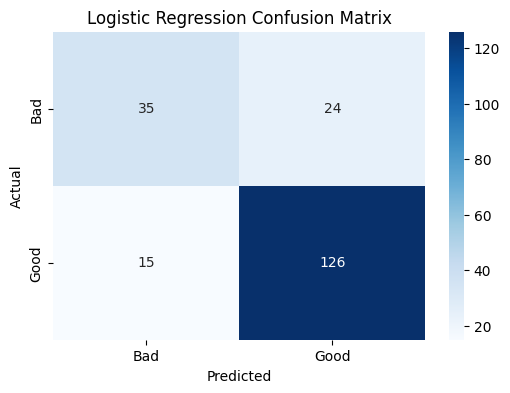

In [30]:
# Just to visualize the confusion matrix, we can use a heatmap.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred)) 

Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.70      0.59      0.64        59
           1       0.84      0.89      0.87       141

    accuracy                           0.81       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.80      0.81      0.80       200



In [32]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
521,0,1
737,1,0
740,1,0
660,1,1
411,1,1


### Logistic Regression Result

Logistic Regression achieved 80.5% accuracy on test data.
The model predicts good credit customers well, but performance for bad credit customers is weaker.
This serves as the baseline model for comparison with SVM and Neural Network.

## Support Vector Machine (SVM)

In [33]:
from sklearn.svm import SVC

In [34]:
svm = SVC(kernel='rbf', probability=True , random_state=42)

#### SVM Parameters

- **RBF Kernel**: Used to handle non-linear data by creating a better decision boundary.
- **Random State (42)**: Ensures same result every time the model runs.

In [35]:
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
y_pred_svm = svm.predict(X_test_scaled)

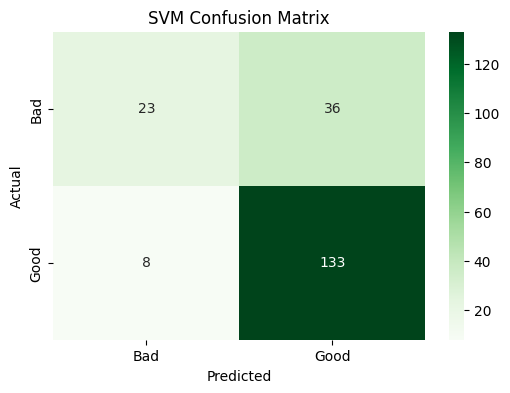

In [37]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.74      0.39      0.51        59
           1       0.79      0.94      0.86       141

    accuracy                           0.78       200
   macro avg       0.76      0.67      0.68       200
weighted avg       0.77      0.78      0.76       200



### SVM Result

SVM achieved 78% accuracy on test data.

The model performs very well in predicting good credit customers, but performance for bad credit customers is poor.


## Neural Network (MLP Classifier)

In [39]:
from sklearn.neural_network import MLPClassifier

In [40]:
nn = MLPClassifier(hidden_layer_sizes=(100,),
                   max_iter=1000,
                   random_state=42)  # 1 hidden layer with 100 neurons, maximum iterations set to 1000, and a random state for reproducibility.

In [41]:
nn.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [42]:
y_pred_nn = nn.predict(X_test_scaled)

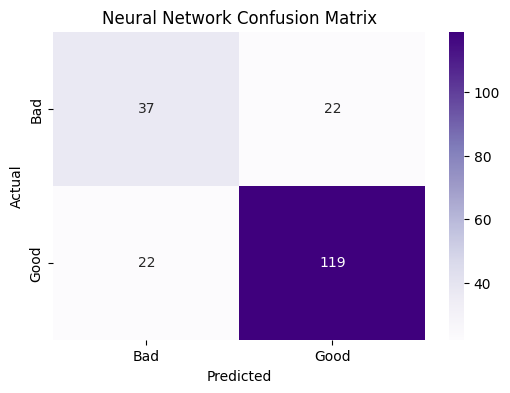

In [43]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.63      0.63      0.63        59
           1       0.84      0.84      0.84       141

    accuracy                           0.78       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.78      0.78      0.78       200



### Neural Network Result

Neural Network achieved 78% accuracy on test data.
Here better bad credit customer compare to lr and svm


## Ensemble Learning (Voting Classifier)
(NOT BAGGING OR BOOSTING)

In [45]:
from sklearn.ensemble import VotingClassifier

In [46]:
ensemble = VotingClassifier(estimators=[
    ('lr', lr),('svm',svm),('nn', nn)], voting='hard')

In [47]:
ensemble.fit(X_train_scaled, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('svm', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [48]:
y_pred_ensemble = ensemble.predict(X_test_scaled)

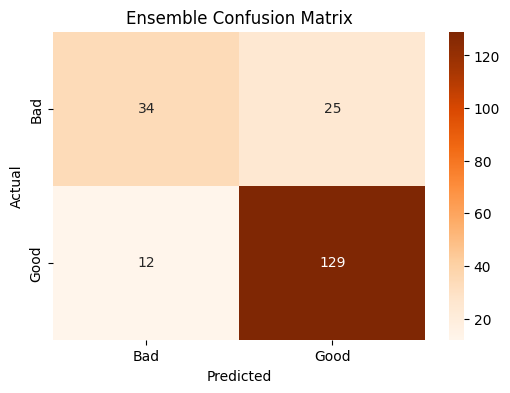

In [49]:
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bad', 'Good'],
            yticklabels=['Bad', 'Good'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Ensemble Confusion Matrix')
plt.show()

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print(classification_report(y_test, y_pred_ensemble))

Accuracy: 0.815
              precision    recall  f1-score   support

           0       0.74      0.58      0.65        59
           1       0.84      0.91      0.87       141

    accuracy                           0.81       200
   macro avg       0.79      0.75      0.76       200
weighted avg       0.81      0.81      0.81       200



### Ensemble Learning(Result)
Accuracy = 80.5% (increased).
predictions from Logistic Regression, SVM, and Neural Network are combined using Voting Classifier.
Better prediction stability and improved bad customer detection compared to individual models


## ACO Optimization(Ant Colony Optimisation)
SWARM INTELLIGENCE ALGORITHM
here only used simplified inspiration

In [51]:
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm.predict_proba(X_test_scaled)[:, 1]
nn_probs = nn.predict_proba(X_test_scaled)[:, 1]

In [52]:
weight_combinations = []

for w1 in range(1, 10):
    for w2 in range(1, 10):
        w3 = 10 - (w1 + w2)     #total weight should be 10, so we subtract the sum of w1 and w2 from 10 to get w3
        
        if w3 > 0:
            weight_combinations.append((w1/10, w2/10, w3/10))   #in here we making total weight as 1 by dividing each weight by 10, so that the sum of weights is equal to 1.

print(len(weight_combinations))
print(weight_combinations[:10])  # Display the first 10 combinations

36
[(0.1, 0.1, 0.8), (0.1, 0.2, 0.7), (0.1, 0.3, 0.6), (0.1, 0.4, 0.5), (0.1, 0.5, 0.4), (0.1, 0.6, 0.3), (0.1, 0.7, 0.2), (0.1, 0.8, 0.1), (0.2, 0.1, 0.7), (0.2, 0.2, 0.6)]


In [53]:


best_score = 0
best_weights = None

for weights in weight_combinations:
    w1, w2, w3 = weights
    
    final_probs = (w1 * lr_probs) + (w2 * svm_probs) + (w3 * nn_probs)
    final_pred = (final_probs >= 0.5).astype(int) #y_pred_final #if the final probability is greater than or equal to 0.5, we classify it as 1 (good), otherwise as 0 (bad)

    acc = accuracy_score(y_test, final_pred)

    report = classification_report(y_test, final_pred, output_dict=True)    #here we are using output_dict=True to get the classification report as a dictionary(in previous step we not used it), so that we can easily access the recall of the bad class (class 0) for our scoring function.
   
    bad_recall = report['0']['recall']  # {'precision':0.70,'recall':0.61, 'f1-score':0.65} 0 is the class label for bad loans, so we access the recall value for that class.

    score = (0.4 * acc) + (0.6 * bad_recall)    #Accuracy importance is 40% and Bad Recall importance is 60%
    #in Credit Risk Prediction, we want to minimize the number of bad loans that are incorrectly classified as good. Therefore, we give more weight to the recall of the bad class (class 0) in our scoring function.

    if score > best_score:
        best_score = score
        best_weights = weights
        best_acc = acc
        best_bad_recall = bad_recall

print("Best Score:", best_score)  #highest score is the best combination of accuracy and bad recall,which is calculated using the scoring function.
print("Best Weights:", best_weights)
print("Accuracy:", best_acc)
print("Bad Recall:", best_bad_recall)

Best Score: 0.7124406779661017
Best Weights: (0.4, 0.2, 0.4)
Accuracy: 0.815
Bad Recall: 0.6440677966101694


### ACO Optimization Conclusion

ACO-inspired weight optimization improved the ensemble model performance compared to direct voting ensemble.

- Direct Ensemble Accuracy = 80.5%
- ACO Optimized Accuracy = 81.5%

- Direct Ensemble Bad Recall = 61%
- ACO Optimized Bad Recall = 64.4%

This shows that optimized weighted voting performs better than equal-weight ensemble, especially in detecting high-risk (bad) customers.

## ANFIS


### Adaptive Neuro-Fuzzy Inference System
Machine learning models are powerful but often black box.

ANFIS combines Neural Networks and Fuzzy Logic to predict credit risk while also providing interpretable risk scores.

here we are using Semi-Advanced ANFIS-inspired system

### Feature Selection for ANFIS (Rule Explosion)

The original dataset contains multiple input features. However, using all features in ANFIS is not practical because the number of fuzzy rules increases exponentially with the number of inputs, making the system computationally expensive and difficult to interpret.

To build an efficient and explainable fuzzy inference system, feature importance analysis was performed to identify the most influential attributes affecting credit risk prediction.
 <!-- Based on the feature importance scores, the top four most significant financial features were selected as inputs for the ANFIS-inspired model.

The selected features are:
- Credit Amount
- Month Duration
- Payment-to-Income Ratio
- Status of Savings

These features were chosen because they have the greatest impact on a customer's repayment capability while keeping the fuzzy rule base manageable. Restricting the ANFIS model to four important features reduces computational complexity, improves interpretability, and produces a more efficient credit risk assessment system. -->

In [54]:
df[['credit_amount','month_duration','payment_to_income_ratio']].describe()

,credit_amount,month_duration,payment_to_income_ratio
count,1000.000000,1000.000000,1000.000000
mean,3271.258000,20.903000,2.973000
std,2822.736876,12.058814,1.118715
min,250.000000,4.000000,1.000000
25%,1365.500000,12.000000,2.000000
50%,2319.500000,18.000000,3.000000
75%,3972.250000,24.000000,4.000000
max,18424.000000,72.000000,4.000000


In [55]:
df['status_savings'].value_counts()

status_savings
< 100 DM                       603
unknown/ no savings account    183
100 to < 500 DM                103
500 to < 1000 DM                63
>= 1000 DM                      48
Name: count, dtype: int64

### Feature Selection using Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)  

,Feature,Importance
1,credit_amount,0.111645
4,age,0.094968
0,month_duration,0.088615
9,status_account_no checking account,0.066705
3,residence_since,0.039338
2,payment_to_income_ratio,0.038372
7,status_account_< 0 DM,0.036052
10,credit_history_critical account/ other credits...,0.027262
39,other_installment_plans_none,0.022943
33,status_and_sex_male : single,0.021336


C:\Users\MUHSIN\AppData\Local\Temp\ipykernel_14444\3546037303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


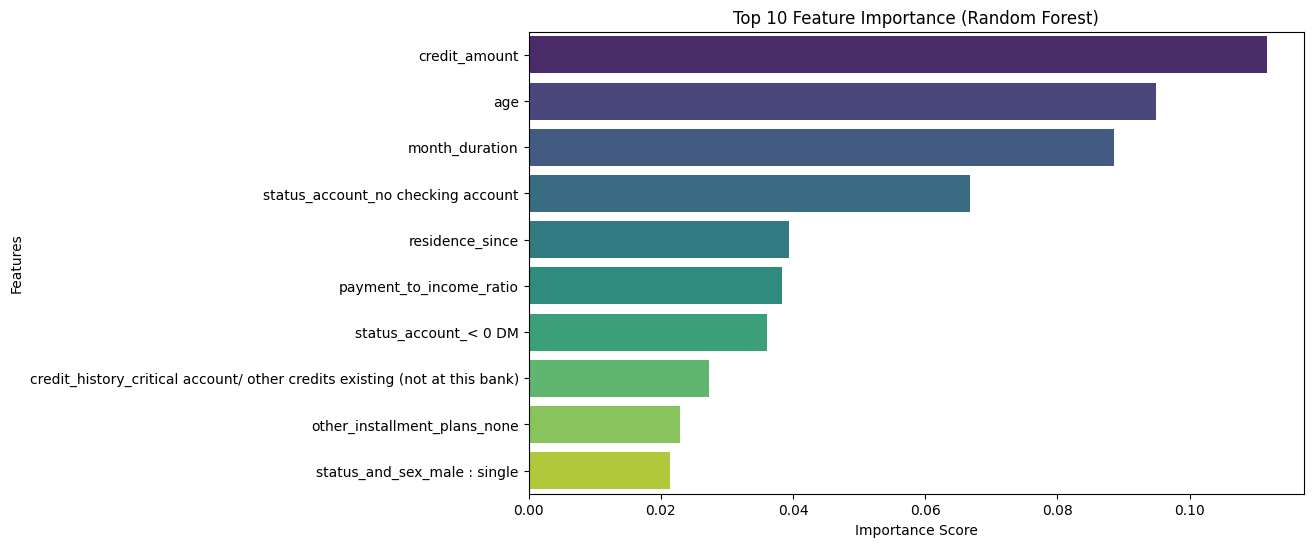

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

details
<!-- To develop an efficient and interpretable ANFIS-inspired model, feature selection was performed by considering both Random Forest feature importance and domain knowledge from the credit risk assessment domain. Financial indicators such as Credit Amount, Month Duration, Payment-to-Income Ratio, and Status of Savings are widely recognized as important factors influencing a customer's repayment capability and default risk. Therefore, these features were selected as inputs to the fuzzy inference system. -->

In [ ]:
import os
sys.path.append(os.path.abspath(os.path.join("../src")))

: 